<a href="https://colab.research.google.com/github/jurewiczM/PUM/blob/regresja/PUM5_regresjanieliniowa_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [8]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

<ipython-input-8-9f69f8392d9a>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [9]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

Zbuduj model benchmarkowy - zwykłą regresję liniową

In [12]:
for column in df.columns:
  df[column].fillna(df[column].mean(), inplace=True)

<ipython-input-12-69eacf26a006>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)


In [13]:
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred)}")
print(f"Błąd kwadratowy: {mean_squared_error(y_test, y_pred)}")
print(f"Błąd bezwzględny: {mean_absolute_error(y_test, y_pred)}")

R^2: 0.8888191777593422
Błąd kwadratowy: 269335248.3646314
Błąd bezwzględny: 11034.937092871918


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data =  pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

               feature        VIF
0                  Age  15.129201
1               Gender   2.047736
2      Education Level   2.330338
3            Job Title   4.892569
4  Years of Experience   9.426853


Spróbuj poprawić wynik używając regresji LASSO

In [18]:
lasso_reg = Lasso(True, precompute=False, copy_X=True, max_iter=1000, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')

lasso_reg.fit(X_train, y_train)

y_pred = lasso_reg.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred)}")
print(f"Błąd kwadratowy: {mean_squared_error(y_test, y_pred)}")
print(f"Błąd bezwzględny: {mean_absolute_error(y_test, y_pred)}")

R^2: 0.8887662245875606
Błąd kwadratowy: 269463527.2834776
Błąd bezwzględny: 11037.772029843061


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [19]:
df['Experience Squared'] = df['Years of Experience'] ** 2

y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred)}")
print(f"Błąd kwadratowy: {mean_squared_error(y_test, y_pred)}")
print(f"Błąd bezwzględny: {mean_absolute_error(y_test, y_pred)}")

R^2: 0.8875719280979623
Błąd kwadratowy: 272356707.37663
Błąd bezwzględny: 10977.000790143727


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy

regresja wyższego rzędu jest uzasadniona?

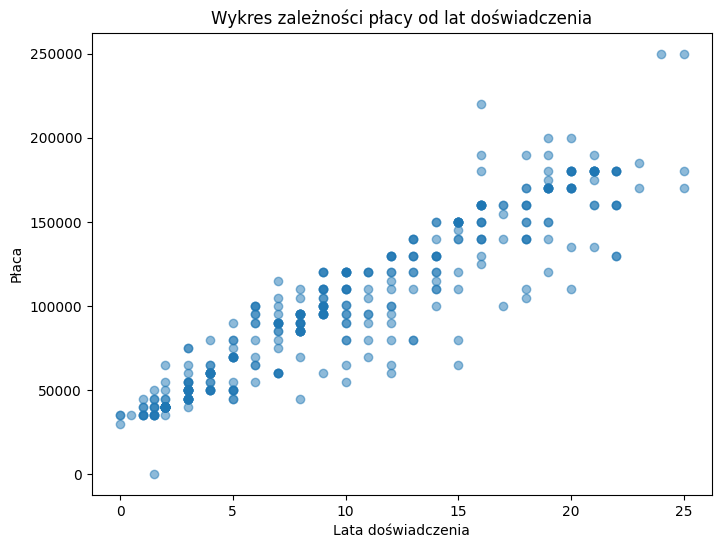

In [20]:


plt.figure(figsize=(8, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.5)
plt.xlabel('Lata doświadczenia')
plt.ylabel('Płaca')
plt.title('Wykres zależności płacy od lat doświadczenia')
plt.show()




Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

In [21]:
from sklearn import neighbors

knn_reg = neighbors.KNeighborsRegressor(n_neighbors=7)
knn_reg.fit(X_train, y_train)

y_pred = knn_reg.predict(X_test)

print(f"R^2: {r2_score(y_test, y_pred)}")
print(f"Błąd kwadratowy: {mean_squared_error(y_test, y_pred)}")
print(f"Błąd bezwzględny: {mean_absolute_error(y_test, y_pred)}")

R^2: 0.8968552547750689
Błąd kwadratowy: 249867873.00898692
Błąd bezwzględny: 11316.544618919952


In [23]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=2, n_repeats=2)

rkf.get_n_splits(X_train, y_train)



4